## Stationary Example

In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from pandas import Series
import numpy as np
from pandas import read_csv

In [3]:
series = pd.read_csv('daily-total-female-births.csv',header=0, index_col=0 )

In [5]:
series.head()

,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


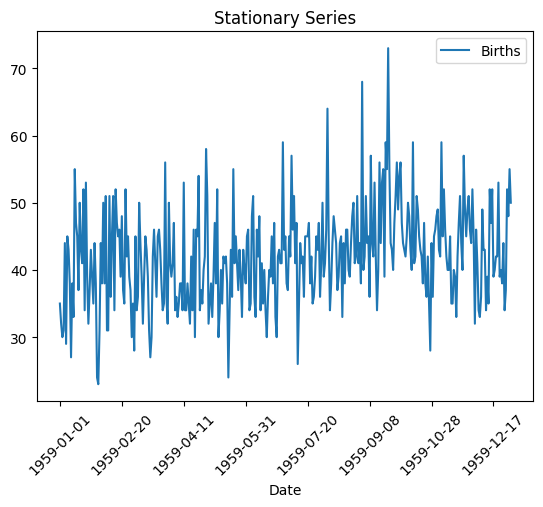

In [6]:
series.plot()
plt.title('Stationary Series')
plt.xticks(rotation = 45)
plt.show()

In [ ]:
X = series.values
result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.808291
p-value: 0.000052
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571


## Interpreting the p-value

## Now the hypotheses become:
Null hypothesis

H_0 : Series is NOT stationary
	​

Alternative hypothesis

H_1 : Series is stationary

## Since

p = 0.000052

and 

0.000052 < 0.05

Reject H_0


Conclusion: the series is stationary.

## Interpreting the test statistic

ADF Statistic: -4.808291

Critical Values:

	1%: -3.449

	5%: -2.870
	
    10%: -2.571


Since

-4.808291 < -3.449

the test statistic is more negative than the 1% critical value.

Conclusion: reject the null hypothesis; the series is stationary.


# Non Stationary Series

In [10]:
series_2=pd.read_csv('airline_passengers.csv',header=0, index_col=0)
X_2 = series_2.values
result_2 = adfuller(X_2)
print('ADF Statistic: %f' % result_2[0])
print('p-value: %f' % result_2[1])
print('Critical Values:')
for key, value in result_2[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


## Since

p =0 .991880

and 

0.991880 > 0.05

Fail to Reject H_0


Conclusion: the series is not stationary.

ADF Statistic: 0.815369

Critical Values:

	1%: -3.449

	5%: -2.870
	
    10%: -2.571


Since

0.815369 > -3.449

the test statistic is more than the 1% critical value.

Conclusion: do not reject the null hypothesis; the series is not stationary.

## Differencing

In [18]:
from datetime import datetime
dateparse = lambda x: datetime.strptime('190'+x, '%Y-%m')
df = read_csv('shampoo_sales.csv')
df.head(1)

,Month,Sales
0,1-01,266.0


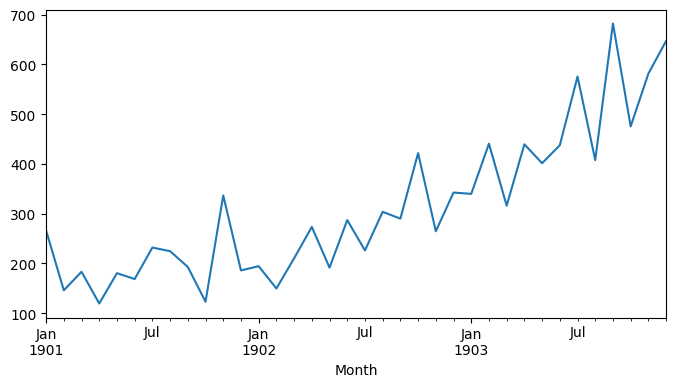

<Axes: xlabel='Month'>

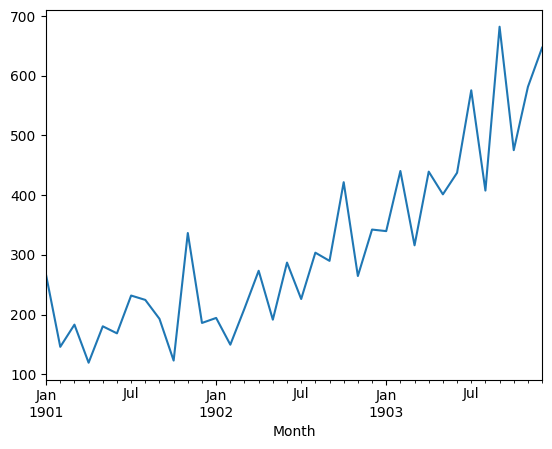

In [19]:
df["Month"] = df["Month"].apply(
    lambda x: datetime.strptime("190" + x, "%Y-%m")
)

df.set_index("Month", inplace=True)

series_3 = df["Sales"]

series_3.plot(figsize=(8,4))
plt.show()
series_3.plot()

In [20]:
X_3=series_3.values
def difference(dataset, interval=1):
 diff = list()
 for i in range(interval, len(dataset)):
     value = dataset[i] - dataset[i - interval]
     diff.append(value)
 return Series(diff)

diff=difference(X_3)

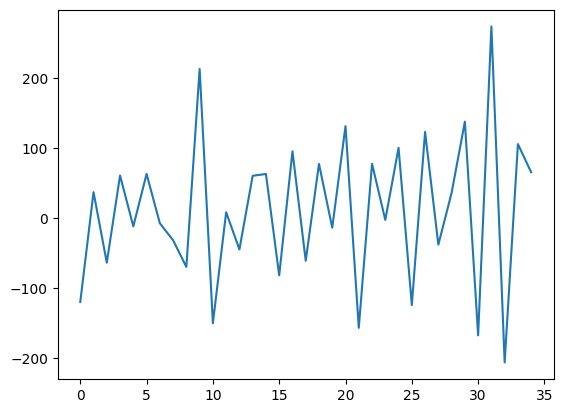

In [21]:
plt.plot(diff)

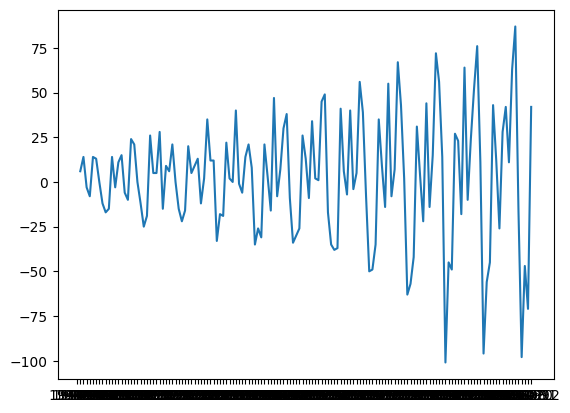

In [22]:
diff_2 = series_2.diff()
plt.plot(diff_2)
plt.show()